# 06 Private-Car Public-Charging Station Queue

This notebook **presents the current vehicle-queueing logic** added to the
private-car charging pipeline (`mobility/cars/station_queue.py`).

It is a *presentation* notebook, not a national run. Every example below is
built from small synthetic data (the same style as
`tests/mobility/cars/test_station_queue.py`), so the whole notebook runs in a
second and is fully reproducible without touching the multi-hundred-GB outputs.

We answer three questions for each part of the model: **why** the choice exists,
**how** the code encodes it, and **what** it does to a concrete set of sessions.

---

### Where this layer sits

```
trip generation -> station matching -> SOC simulation -> baseline station curve
                                                              |
                                          (--enable-queue-model only)
                                                              v
                                            *** THIS LAYER: queue post-processing ***
```

The queue layer is a **pure post-processing layer at the very end of the
pipeline**. It treats the baseline's public charging sessions as *requested
demand*, then re-schedules that demand through a **deterministic, per-station,
first-come-first-served (FCFS), finite-connector queue**.

It does **not** change trip generation, station matching, the SOC equations,
destination choice, or the uncontrolled baseline outputs. Baseline files are
left untouched; only extra `*_queue_aware_*` files are written. The whole layer
is gated behind the `--enable-queue-model` flag.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from IPython.display import Markdown, display

# Locate the repo root (the folder that contains `mobility/`) so this notebook
# runs whether launched from the repo root or from notebooks/.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "mobility").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from mobility.cars.station_queue import (
    QueueModelConfig,
    QUEUE_MODEL_NAME,
    build_public_session_demand_from_events,
    build_station_capacity_table,
    run_queue_model,
    aggregate_queue_curve_15min,
    aggregate_queue_curve_hourly,
    build_station_queue_summary,
    build_queue_baseline_comparison,
    run_queue_model_for_events,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print("queue model name:", QUEUE_MODEL_NAME)
print("repo root:", REPO_ROOT)

queue model name: deterministic_fcfs_finite_connectors
repo root: /home/mazhichuan/Projects/Modelling


## 1. The data flow at a glance

The layer is five steps. Each is one (or a few) public functions in
`mobility/cars/station_queue.py`.


In [2]:
flow = pd.DataFrame(
    [
        ("1. Take demand",
         "build_public_session_demand_from_events",
         "Keep only charging_type=='public_current_lsoa' events. Each becomes a session: "
         "arrival_time / window_end_time come from the FULL parking-dwell window "
         "(parking_event.start_time/end_time), NOT the charging duration — so there is genuine slack to wait."),
        ("2. Build capacity",
         "build_station_capacity_table",
         "Per-station finite servers. Prefer a real connector table (count + power summed by station); "
         "otherwise fall back to a synthetic count from station total kW. The source is recorded honestly."),
        ("3. Schedule",
         "run_queue_model -> _schedule_station_group",
         "Each station independent. Sessions sorted by (arrival, session_id). First-available connector wins. "
         "Energy not deliverable before the window closes is reported as UNMET (no silent dwell extension)."),
        ("4. Aggregate",
         "aggregate_queue_curve_15min / _hourly",
         "Slice service intervals and waiting intervals into 15-min bins -> station delayed load, "
         "occupied connectors, queue length, utilisation."),
        ("5. Summarise / compare",
         "build_station_queue_summary + build_queue_baseline_comparison",
         "Per-station waiting / rejection / unmet / utilisation, and no-queue baseline vs queue-aware "
         "energy & peak power."),
    ],
    columns=["step", "function(s)", "what it does"],
)
display(flow.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

step,function(s),what it does
1. Take demand,build_public_session_demand_from_events,"Keep only charging_type=='public_current_lsoa' events. Each becomes a session: arrival_time / window_end_time come from the FULL parking-dwell window (parking_event.start_time/end_time), NOT the charging duration — so there is genuine slack to wait."
2. Build capacity,build_station_capacity_table,Per-station finite servers. Prefer a real connector table (count + power summed by station); otherwise fall back to a synthetic count from station total kW. The source is recorded honestly.
3. Schedule,run_queue_model -> _schedule_station_group,"Each station independent. Sessions sorted by (arrival, session_id). First-available connector wins. Energy not deliverable before the window closes is reported as UNMET (no silent dwell extension)."
4. Aggregate,aggregate_queue_curve_15min / _hourly,"Slice service intervals and waiting intervals into 15-min bins -> station delayed load, occupied connectors, queue length, utilisation."
5. Summarise / compare,build_station_queue_summary + build_queue_baseline_comparison,"Per-station waiting / rejection / unmet / utilisation, and no-queue baseline vs queue-aware energy & peak power."


## 2. Step 2 — Station capacity (finite servers)

**Why.** A station can only serve as many cars at once as it has connectors,
and each connector has a finite power. The baseline pipeline has no such state;
this is the constraint the queue layer adds.

**How.**
- If a **connector table** is supplied (the production default is
  `data/UK_OCM_connectors_expanded_with_bus_and_LAD_LSOA.csv`, one row per
  device), connector counts and powers are **summed per station** and
  `capacity_source = "connector_table"`.
- Without connector rows, the model **falls back**: it derives a synthetic
  connector count from the station's total kW and
  `fallback_connector_power_kw` (default 7 kW), and labels
  `capacity_source = "fallback_from_station_total_capacity_kw"`. This is an
  **assumption, not observed inventory**, and is flagged as such.

Below: station `101` has no connector rows (fallback), station `202` has a
connector table (observed).


In [3]:
station_metadata = pd.DataFrame(
    {"station_id": ["101", "202"], "total_capacity_kw": [21.0, 50.0]}
)
connectors = pd.DataFrame(
    {"StationID": [202, 202], "Power_kW": [50.0, 22.0], "Quantity": [2, 1]}
)

capacity_demo = build_station_capacity_table(
    station_metadata,
    connector_table=connectors,
    config=QueueModelConfig(fallback_connector_power_kw=7.0),
)
display(capacity_demo)

print("station 101: 21 kW total / 7 kW fallback per connector -> 3 synthetic connectors (assumption)")
print("station 202: 2x50 kW + 1x22 kW connectors -> 3 connectors, 122 kW observed")

,station_id,connector_count,connector_power_kw,station_capacity_kw,capacity_source
0,101,3,7.000000,21.0,fallback_from_station_total_capacity_kw
1,202,3,40.666667,122.0,connector_table


station 101: 21 kW total / 7 kW fallback per connector -> 3 synthetic connectors (assumption)
station 202: 2x50 kW + 1x22 kW connectors -> 3 connectors, 122 kW observed


## 3. Step 3 — The scheduling core (FCFS, finite connectors)

This is the heart of the model: `_schedule_station_group`. Per station, per
session, in arrival order:

1. **Free expired waits** from the live queue (anyone whose wait ended at/before
   this arrival has left the queue).
2. **Pick the earliest-free connector**; `start = max(arrival, connector_free_time)`.
3. **Per-connector power is homogenised**: `connector_power = station_capacity_kw / connector_count`,
   and the delivered power is `min(requested_power, connector_power)`.
   *(This is the single most important interpretation caveat — see §6.)*
4. **Service may not run past the parking window** (`allow_service_after_window=False`
   by default). Energy that cannot be delivered before the window closes is
   recorded as **`unmet_energy_kwh`** — the dwell is never silently extended.
5. **Waiting time** = arrival → service start. If a connector never frees up
   before the window closes, the session is **`rejected`** (delivered = 0, all
   energy unmet).

Each session is classified into one `queue_status`:

| status | meaning |
|---|---|
| `served` | got a connector immediately, full energy delivered |
| `delayed_served` | waited, but still received full energy within the window |
| `partial_unmet` | got a connector but the window closed before full energy |
| `rejected` | never got a connector before the window closed (delivered 0) |


### A worked scenario at one busy station

Station **`PUB1`** has **2 connectors × 7 kW**. We send five sessions through
it, designed to land on **all four** statuses. Read the table top-to-bottom in
arrival order.


In [4]:
# 2 connectors x 7 kW.
pub1_capacity = pd.DataFrame(
    {
        "station_id": ["PUB1"],
        "connector_count": [2],
        "connector_power_kw": [7.0],
        "station_capacity_kw": [14.0],
        "capacity_source": ["demo_2x7kW"],
    }
)

D = "2025-01-01 "
sessions = pd.DataFrame(
    {
        "session_id":          ["s1",        "s2",        "s3",        "s4",        "s5"],
        "vehicle_id":          ["v1",        "v2",        "v3",        "v4",        "v5"],
        "station_id":          ["PUB1"] * 5,
        "arrival_time":        pd.to_datetime([D+"18:00", D+"18:00", D+"18:15", D+"18:45", D+"19:00"]),
        "window_end_time":     pd.to_datetime([D+"19:00", D+"22:00", D+"21:00", D+"20:30", D+"19:45"]),
        "requested_energy_kwh":[3.5,         14.0,        7.0,         21.0,        7.0],
        "requested_power_kw":  [7.0,         7.0,         7.0,         7.0,         7.0],
    }
)
display(sessions)

,session_id,vehicle_id,station_id,arrival_time,window_end_time,requested_energy_kwh,requested_power_kw
0,s1,v1,PUB1,2025-01-01 18:00:00,2025-01-01 19:00:00,3.5,7.0
1,s2,v2,PUB1,2025-01-01 18:00:00,2025-01-01 22:00:00,14.0,7.0
2,s3,v3,PUB1,2025-01-01 18:15:00,2025-01-01 21:00:00,7.0,7.0
3,s4,v4,PUB1,2025-01-01 18:45:00,2025-01-01 20:30:00,21.0,7.0
4,s5,v5,PUB1,2025-01-01 19:00:00,2025-01-01 19:45:00,7.0,7.0


In [5]:
queued = run_queue_model(sessions, pub1_capacity)

show_cols = [
    "session_id", "arrival_time", "window_end_time", "connector_id",
    "scheduled_service_start_time", "scheduled_service_end_time",
    "waiting_time_min", "queue_length_on_arrival",
    "requested_energy_kwh", "delivered_energy_after_queue_kwh", "unmet_energy_kwh",
    "queue_status",
]
display(queued[show_cols])

print("delivered total:", queued["delivered_energy_after_queue_kwh"].sum(), "kWh")
print("requested total:", queued["requested_energy_kwh"].sum(), "kWh")
print("unmet total:    ", queued["unmet_energy_kwh"].sum(), "kWh")
print()
print("status counts:")
print(queued["queue_status"].value_counts().to_string())

,session_id,arrival_time,window_end_time,connector_id,scheduled_service_start_time,scheduled_service_end_time,waiting_time_min,queue_length_on_arrival,requested_energy_kwh,delivered_energy_after_queue_kwh,unmet_energy_kwh,queue_status
0,s1,2025-01-01 18:00:00,2025-01-01 19:00:00,PUB1_conn_1,2025-01-01 18:00:00,2025-01-01 18:30:00,0.0,0,3.5,3.5,0.0,served
1,s2,2025-01-01 18:00:00,2025-01-01 22:00:00,PUB1_conn_2,2025-01-01 18:00:00,2025-01-01 20:00:00,0.0,0,14.0,14.0,0.0,served
2,s3,2025-01-01 18:15:00,2025-01-01 21:00:00,PUB1_conn_1,2025-01-01 18:30:00,2025-01-01 19:30:00,15.0,1,7.0,7.0,0.0,delayed_served
3,s4,2025-01-01 18:45:00,2025-01-01 20:30:00,PUB1_conn_1,2025-01-01 19:30:00,2025-01-01 20:30:00,45.0,1,21.0,7.0,14.0,partial_unmet
4,s5,2025-01-01 19:00:00,2025-01-01 19:45:00,NaN,NaT,NaT,45.0,2,7.0,0.0,7.0,rejected


delivered total: 31.5 kWh
requested total: 52.5 kWh
unmet total:     21.0 kWh

status counts:
queue_status
served            2
delayed_served    1
partial_unmet     1
rejected          1


**Reading the result**

- **`s1`** (`served`): connector 1 free at 18:00, charges 0.5 h, done 18:30.
- **`s2`** (`served`): connector 2 free at 18:00, charges 2 h, done 20:00 (holds connector 2 the whole time).
- **`s3`** (`delayed_served`): arrives 18:15, both connectors busy; waits for
  connector 1 (free 18:30), 15 min wait, then full 7 kWh within its window.
- **`s4`** (`partial_unmet`): needs 3 h but only gets a connector at 19:30 and
  its window closes 20:30 → only 7 of 21 kWh delivered, **14 kWh unmet**.
- **`s5`** (`rejected`): the earliest connector frees at 20:00, after its 19:45
  window closes → **0 kWh delivered, 7 kWh unmet**, and it sat in the queue
  behind `s4` (`queue_length_on_arrival = 2`).

> **Note on `queue_length_on_arrival`** — it counts the concurrent waiting
> sessions *including this one* once it joins the queue. So the per-station
> `max_queue_length` is the peak number of cars waiting at once (here 2), not
> "how many were ahead of me".


### Visualising the schedule

The Gantt view makes the FCFS mechanics obvious: solid bars are connector
service (coloured by status); hatched bars are time spent **waiting** in the
queue; the triangles mark arrivals.


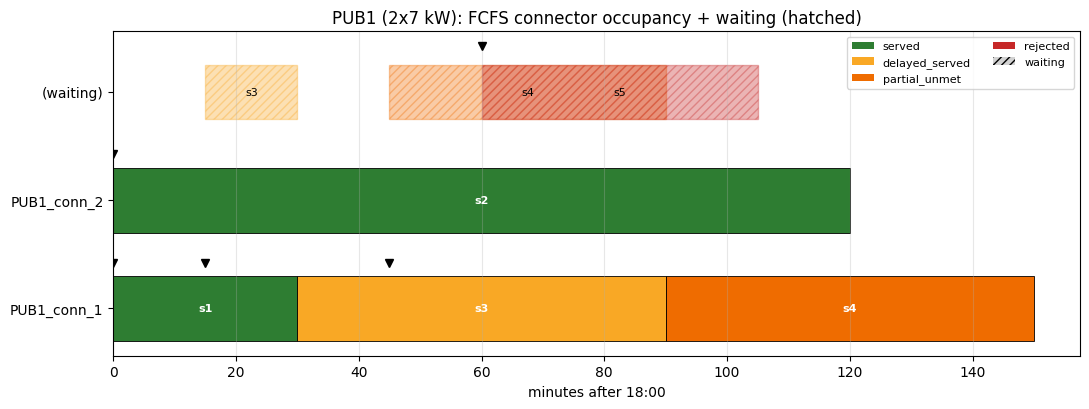

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.2))

status_color = {
    "served": "#2e7d32",
    "delayed_served": "#f9a825",
    "partial_unmet": "#ef6c00",
    "rejected": "#c62828",
}

# Lanes: one per connector, plus a "queue / waiting" lane on top.
connector_ids = sorted(
    queued["connector_id"].dropna().unique().tolist()
)
lanes = connector_ids + ["(waiting)"]
lane_y = {name: i for i, name in enumerate(lanes)}

t0 = queued["arrival_time"].min()
def to_min(ts):
    return (pd.Timestamp(ts) - t0).total_seconds() / 60.0

for row in queued.itertuples(index=False):
    status = row.queue_status
    color = status_color[status]
    # waiting bar (arrival -> queue_wait_end) on the waiting lane
    w0 = to_min(row.arrival_time)
    w1 = to_min(row.queue_wait_end_time)
    if w1 > w0:
        ax.barh(lane_y["(waiting)"], w1 - w0, left=w0, height=0.5,
                color=color, alpha=0.35, hatch="////", edgecolor=color)
        ax.text((w0 + w1) / 2, lane_y["(waiting)"], row.session_id,
                ha="center", va="center", fontsize=8)
    # service bar on its connector lane
    if pd.notna(row.scheduled_service_start_time) and pd.notna(row.scheduled_service_end_time):
        s0 = to_min(row.scheduled_service_start_time)
        s1 = to_min(row.scheduled_service_end_time)
        y = lane_y[str(row.connector_id)]
        ax.barh(y, s1 - s0, left=s0, height=0.6, color=color, edgecolor="black", linewidth=0.6)
        ax.text((s0 + s1) / 2, y, f"{row.session_id}", ha="center", va="center",
                fontsize=8, color="white", fontweight="bold")
    # arrival marker
    ax.plot(to_min(row.arrival_time), lane_y.get(str(row.connector_id), lane_y["(waiting)"]) + 0.42,
            marker="v", color="black", markersize=6)

ax.set_yticks(range(len(lanes)))
ax.set_yticklabels(lanes)
ax.set_xlabel(f"minutes after {t0:%H:%M}")
ax.set_title("PUB1 (2x7 kW): FCFS connector occupancy + waiting (hatched)")
ax.grid(axis="x", alpha=0.3)
legend = [Patch(facecolor=c, label=s) for s, c in status_color.items()]
legend.append(Patch(facecolor="grey", alpha=0.35, hatch="////", label="waiting"))
ax.legend(handles=legend, loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 4. Step 4 — Aggregating to the 15-minute station curve

`aggregate_queue_curve_15min` slices each session's **service** interval and
**waiting** interval into 15-minute bins and rolls them up per station. The
delivered power in a bin is `delivered_energy / service_duration` spread over
the overlap, so energy is conserved bin-by-bin.

Key columns: `energy_kwh`, `avg_power_kw`, `occupied_connector_count`,
`queued_session_count`, `bin_utilization_rate` (occupied connector-time ÷
connector-count × bin).


,time_bin_start,energy_kwh,avg_power_kw,occupied_connector_count,queued_session_count,bin_utilization_rate
0,2025-01-01 18:00:00,3.50,14.0,2,0,1.0
1,2025-01-01 18:15:00,3.50,14.0,2,1,1.0
2,2025-01-01 18:30:00,3.50,14.0,2,0,1.0
3,2025-01-01 18:45:00,3.50,14.0,2,1,1.0
4,2025-01-01 19:00:00,3.50,14.0,2,2,1.0
5,2025-01-01 19:15:00,3.50,14.0,2,2,1.0
6,2025-01-01 19:30:00,3.50,14.0,2,1,1.0
7,2025-01-01 19:45:00,3.50,14.0,2,0,1.0
8,2025-01-01 20:00:00,1.75,7.0,1,0,0.5
9,2025-01-01 20:15:00,1.75,7.0,1,0,0.5


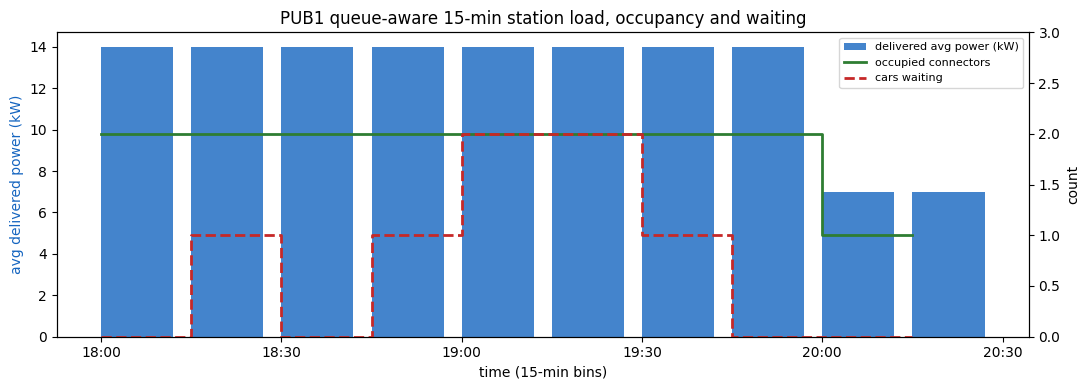

In [7]:
curve = aggregate_queue_curve_15min(queued)
display(curve[[
    "time_bin_start", "energy_kwh", "avg_power_kw",
    "occupied_connector_count", "queued_session_count", "bin_utilization_rate",
]])

fig, ax1 = plt.subplots(figsize=(11, 4))
x = pd.to_datetime(curve["time_bin_start"])
ax1.bar(x, curve["avg_power_kw"], width=pd.Timedelta(minutes=12), align="edge",
        color="#1565c0", alpha=0.8, label="delivered avg power (kW)")
ax1.set_ylabel("avg delivered power (kW)", color="#1565c0")
ax1.set_xlabel("time (15-min bins)")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax2 = ax1.twinx()
ax2.step(x, curve["occupied_connector_count"], where="post", color="#2e7d32",
         linewidth=2, label="occupied connectors")
ax2.step(x, curve["queued_session_count"], where="post", color="#c62828",
         linewidth=2, linestyle="--", label="cars waiting")
ax2.set_ylabel("count")
ax2.set_ylim(0, max(3, curve["occupied_connector_count"].max() + 1))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
ax1.set_title("PUB1 queue-aware 15-min station load, occupancy and waiting")
plt.tight_layout()
plt.show()

## 5. Step 5 — Station summary and baseline comparison

`build_station_queue_summary` produces the per-station service-quality metrics;
`build_queue_baseline_comparison` puts the no-queue baseline next to the
queue-aware load.

To make the comparison self-contained, we build an **illustrative baseline**
here that charges every session **immediately at its requested power** (no
contention, no per-connector cap) — i.e. the "infinite, uncapped infrastructure"
counterfactual. In a real run the baseline is the existing
`station_charging_curve_15min_{year}.parquet`.


In [8]:
summary = build_station_queue_summary(queued)
display(summary[[
    "station_id", "session_count", "delayed_session_count", "rejected_session_count",
    "unmet_session_count", "requested_energy_kwh", "delivered_energy_after_queue_kwh",
    "unmet_energy_kwh", "average_waiting_time_min", "p95_waiting_time_min",
    "max_queue_length", "connector_count", "station_capacity_kw",
    "study_period_h", "station_utilization_rate", "capacity_source",
]])

,station_id,session_count,delayed_session_count,rejected_session_count,unmet_session_count,requested_energy_kwh,delivered_energy_after_queue_kwh,unmet_energy_kwh,average_waiting_time_min,p95_waiting_time_min,max_queue_length,connector_count,station_capacity_kw,study_period_h,station_utilization_rate,capacity_source
0,PUB1,5,3,1,2,52.5,31.5,21.0,21.0,45.0,2,2,14.0,4.0,0.5625,demo_2x7kW


In [9]:
def illustrative_baseline_curve(sessions: pd.DataFrame, bin_minutes: int = 15) -> pd.DataFrame:
    """Each session charges immediately at its requested power until its energy
    is met or its window closes — unlimited connectors, no per-connector cap."""
    step_h = bin_minutes / 60.0
    rows = []
    for r in sessions.itertuples(index=False):
        power = float(r.requested_power_kw)
        if power <= 0:
            continue
        dur_h = float(r.requested_energy_kwh) / power
        end = min(pd.Timestamp(r.arrival_time) + pd.Timedelta(hours=dur_h),
                  pd.Timestamp(r.window_end_time))
        t = pd.Timestamp(r.arrival_time).floor(f"{bin_minutes}min")
        while t < end:
            b_end = t + pd.Timedelta(minutes=bin_minutes)
            overlap_h = (min(b_end, end) - max(t, pd.Timestamp(r.arrival_time))).total_seconds() / 3600.0
            if overlap_h > 0:
                rows.append({"station_id": r.station_id, "time_bin_start": t,
                             "time_bin_end": b_end, "energy_kwh": power * overlap_h})
            t = b_end
    curve = (pd.DataFrame(rows)
             .groupby(["station_id", "time_bin_start", "time_bin_end"], as_index=False)["energy_kwh"].sum())
    curve["avg_power_kw"] = curve["energy_kwh"] / step_h
    return curve

baseline_curve = illustrative_baseline_curve(sessions)
comparison = build_queue_baseline_comparison(baseline_curve, curve, summary)
display(comparison[[
    "station_id", "baseline_energy_kwh", "queue_energy_kwh", "energy_delta_kwh",
    "unmet_energy_kwh", "baseline_peak_power_kw", "queue_peak_power_kw", "peak_power_delta_kw",
    "rejected_session_count", "p95_waiting_time_min", "max_queue_length", "station_utilization_rate",
]])

,station_id,baseline_energy_kwh,queue_energy_kwh,energy_delta_kwh,unmet_energy_kwh,baseline_peak_power_kw,queue_peak_power_kw,peak_power_delta_kw,rejected_session_count,p95_waiting_time_min,max_queue_length,station_utilization_rate
0,PUB1,42.0,31.5,-10.5,21.0,28.0,14.0,-14.0,1,45.0,2,0.5625


## 6. ⚠️ Interpretation caveat: two effects are mixed in the energy delta

This is the single most important thing to keep in mind when reading
`queue_comparison`. The energy/peak difference between baseline and queue-aware
load mixes **two distinct causes**:

1. **Real queue congestion** — cars wait or are rejected because connectors are busy.
2. **Per-connector power capping** — the baseline lets one car draw up to the
   *whole station* (`min(station_total_kW, car_power)`), while the queue model
   caps each car at the *single-connector* power (`station_kW / connector_count`).

Effect (2) reduces delivered power and peak **even with zero waiting**. Below: a
station with 4×7 kW connectors and a single fast 11 kW car, alone. There is no
queue at all, yet the delivered power drops from 11 kW to 7 kW.


In [10]:
solo_capacity = pd.DataFrame(
    {"station_id": ["FAST1"], "connector_count": [4], "connector_power_kw": [7.0],
     "station_capacity_kw": [28.0], "capacity_source": ["demo_4x7kW"]}
)
solo_session = pd.DataFrame(
    {"session_id": ["only"], "vehicle_id": ["vx"], "station_id": ["FAST1"],
     "arrival_time": pd.to_datetime(["2025-01-01 12:00"]),
     "window_end_time": pd.to_datetime(["2025-01-01 16:00"]),
     "requested_energy_kwh": [14.0], "requested_power_kw": [11.0]}
)
solo = run_queue_model(solo_session, solo_capacity)
print("baseline would draw:  min(station 28 kW, car 11 kW) = 11 kW  -> 14 kWh in ~1.27 h")
print(f"queue model draws:    min(connector 7 kW, car 11 kW) = "
      f"{solo['delivered_energy_after_queue_kwh'].iloc[0] / (solo['service_duration_min'].iloc[0]/60):.0f} kW"
      f"  -> 14 kWh in {solo['service_duration_min'].iloc[0]/60:.2f} h")
print("waiting_time_min:", float(solo["waiting_time_min"].iloc[0]), "(no queue at all)")
print()
print("=> the queue model is physically MORE correct (a car can't pull 11 kW from a 7 kW plug),")
print("   but any 'peak reduction' it reports blends congestion with this single-connector cap.")
print("   To attribute pure queueing, compare against a single-connector-power-but-no-contention baseline,")
print("   or state this explicitly in the report. The current queue_model_report does not flag it.")

baseline would draw:  min(station 28 kW, car 11 kW) = 11 kW  -> 14 kWh in ~1.27 h
queue model draws:    min(connector 7 kW, car 11 kW) = 7 kW  -> 14 kWh in 2.00 h
waiting_time_min: 0.0 (no queue at all)

=> the queue model is physically MORE correct (a car can't pull 11 kW from a 7 kW plug),
   but any 'peak reduction' it reports blends congestion with this single-connector cap.
   To attribute pure queueing, compare against a single-connector-power-but-no-contention baseline,
   or state this explicitly in the report. The current queue_model_report does not flag it.


## 7. The production entry point: `run_queue_model_for_events`

In a real run the layer is driven from the baseline charging-event table.
`build_public_session_demand_from_events` keeps only
`charging_type == "public_current_lsoa"` rows (home and failed events are
dropped), and `run_queue_model_for_events` chains all five steps and returns
every output frame in one dict.


In [11]:
events = pd.DataFrame(
    {
        "event_id":          ["home1", "pub1", "pub2", "failed1"],
        "ev_id":             ["v1", "v2", "v3", "v4"],
        "charging_type":     ["home", "public_current_lsoa", "public_current_lsoa", "failed_public_charging"],
        "station_id":        [None, "PUB1", "PUB1", None],
        "charging_start_time": pd.to_datetime(["2025-01-01 01:00", "2025-01-01 18:00",
                                               "2025-01-01 18:10", "2025-01-01 09:00"]),
        "charging_end_time":   pd.to_datetime(["2025-01-01 06:00", "2025-01-01 20:00",
                                               "2025-01-01 19:00", "2025-01-01 10:00"]),
        "charged_energy_kwh":  [20.0, 14.0, 7.0, 0.0],
        "charging_power_kw":   [7.0, 7.0, 7.0, 0.0],
    }
)

demand = build_public_session_demand_from_events(events)
print("public sessions kept (home + failed dropped):")
display(demand)

outputs = run_queue_model_for_events(
    events,
    station_metadata=pd.DataFrame({"station_id": ["PUB1"], "total_capacity_kw": [14.0]}),
    baseline_station_curve=None,
    connector_table=None,                       # -> fallback capacity
    config=QueueModelConfig(fallback_connector_power_kw=7.0),
    year=2025,
)
print("\nreturned frames:", list(outputs.keys()))
print("capacity_source used:", outputs["station_capacity"]["capacity_source"].iloc[0])

public sessions kept (home + failed dropped):


,session_id,vehicle_id,station_id,arrival_time,window_end_time,requested_energy_kwh,requested_power_kw
0,pub1,v2,PUB1,2025-01-01 18:00:00,2025-01-01 20:00:00,14.0,7.0
1,pub2,v3,PUB1,2025-01-01 18:10:00,2025-01-01 19:00:00,7.0,7.0



returned frames: ['queue_session_demand', 'station_capacity', 'queue_sessions', 'queue_curve_15min', 'queue_curve_hourly', 'queue_summary', 'queue_comparison']
capacity_source used: fallback_from_station_total_capacity_kw


## 8. Configuration knobs and how to run it for real

`QueueModelConfig` controls the model:

| field | default | meaning |
|---|---|---|
| `time_resolution_minutes` | 15 | aggregation bin width |
| `fallback_connector_power_kw` | 7.0 | assumed per-connector kW when no connector table |
| `fallback_connector_count` | `None` | force a fixed fallback connector count instead of deriving from kW |
| `allow_service_after_window` | `False` | if `True`, service may run past the parking window (turns unmet into delivered) |
| `max_delay_min` | 0.0 | reserved tolerance knob |
| `availability_model` | `"deterministic"` | only deterministic FCFS is implemented (no random outages yet) |

**Run on existing baseline outputs** (queue-only post-processing; uses
`data/UK_OCM_connectors_expanded_with_bus_and_LAD_LSOA.csv` by default):

```bash
python scripts/run_privatecar_station_queue.py \
  --input-dir outputs/privatecar_charging_curves_2025_sample \
  --output-dir outputs/privatecar_charging_curves_2025_sample \
  --year 2025
```

**Generate baseline + queue outputs in one small pass:**

```bash
python scripts/run_privatecar_charging_curves.py \
  --max-vehicles 5 --chunk-size 5 --skip-web-json \
  --enable-queue-model --output-dir outputs/privatecar_queue_smoke_2025
```

> **Scale warning.** A full national queue run holds every public session and
> every per-session × per-bin row in memory. Before running nationally, shard or
> partition **by station** (all sessions for a station must share one queue run
> for the FCFS logic to be correct). See `docs/privatecar_station_queue.md`.


## 9. Assumptions and limitations (what this layer does NOT do)

- **No feedback into SOC or trip feasibility.** Delayed/unmet/rejected public
  charging is *reported*, not fed back into the SOC walk, later-trip feasibility,
  destination choice, or charging rescheduling. This is a deliberate boundary.
- **Deterministic FCFS only.** No random outages, broken connectors,
  payment/network failures, plug-type compatibility, or driver-abandonment model.
- **Fallback connector counts are assumptions**, clearly labelled in
  `capacity_source`, not observed inventory — unless a connector table is supplied.
- **Energy delta mixes congestion and per-connector capping** (§6); the report
  does not yet separate them.
- **Baseline is never modified** — only `*_queue_aware_*` files are added.

This notebook used only synthetic data; **do not read any number here as a
national estimate.**
